In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "..", "..", ".."))  # activate docs/

  Activating project at `~/Documents/Uni/Courses/26_HTN/Qritical.jl/docs`


In [2]:
using LinearAlgebra, Random, Statistics, Qritical
using CairoMakie

L   = 10
dof = SpinHalf()
g   = Chain(L)
println("MBL study: L=$L spin-½ chain")

MBL study: L=10 spin-½ chain


# Ex 9. Many-Body Localization and Imaginary-Time Ground State

Two problems in one:

**Part A — Imaginary-time TEBD** finds the ground state of the clean XXZ chain by
evolving $|\psi(\tau)\rangle = e^{-H\tau}|\psi_0\rangle / \|\cdot\|$ with $\tau\to\infty$.
The norm diverges exponentially, so we re-canonicalize after each step.

**Part B — MBL disorder** adds random on-site fields $h_i \in [-W, W]$ to the Hamiltonian.
Above the MBL critical disorder $W_c \approx 3.5$, all eigenstates localize and entanglement
growth saturates to an area law instead of growing linearly.

## Part A — Ground state via imaginary-time evolution

$e^{-H\tau}$ projects out excited states exponentially in $\tau$.
After sufficient imaginary time, the normalized state converges to $|E_0\rangle$.

In [3]:
H_clean = XXZ(g; J=1.0, Jz=1.0, h=0.0)   # isotropic Heisenberg
W_clean = MPO(H_clean)

# ED reference ground state energy
gs_ed = solve(H_clean, GroundState(), ExactDiagonalization(:ground))
println("ED ground state energy (L=$L): ", round(gs_ed.energy; sigdigits=8))

ED ground state energy (L=10): -4.2580352


In [4]:
# Imaginary-time TEBD on a canonical MPS.
# e^{-Hτ} is non-unitary: renormalize (canonicalize) each step and divide
# ⟨H⟩ by ⟨ψ|ψ⟩ to read off the variational energy.
dτ     = 0.05
nsteps = 60
D      = 32

# Start from the Néel state (non-zero overlap with the GS)
ψ_it = canonicalize(neel_state(g; dof=dof), LeftCanonical())

E_history = Float64[]
for step in 1:nsteps
    ψ_it = trotter_step(ψ_it, H_clean, dτ, SuzukiTrotter(2);
                        axis=ImaginaryTime(), trunc=MaxBondDimTrunc(D))
    ψ_it = canonicalize(ψ_it, LeftCanonical())
    E    = real(expect(ψ_it, W_clean)) / real(overlap(ψ_it, ψ_it))
    push!(E_history, E)
    global ψ_it
end

println("Final imaginary-time energy: ", round(E_history[end]; sigdigits=8))
println("ED exact:                    ", round(gs_ed.energy;    sigdigits=8))
println("Error:                       ", round(abs(E_history[end] - gs_ed.energy); sigdigits=3))

Final imaginary-time energy: -4.1932716
ED exact:                    -4.2580352
Error:                       0.0648


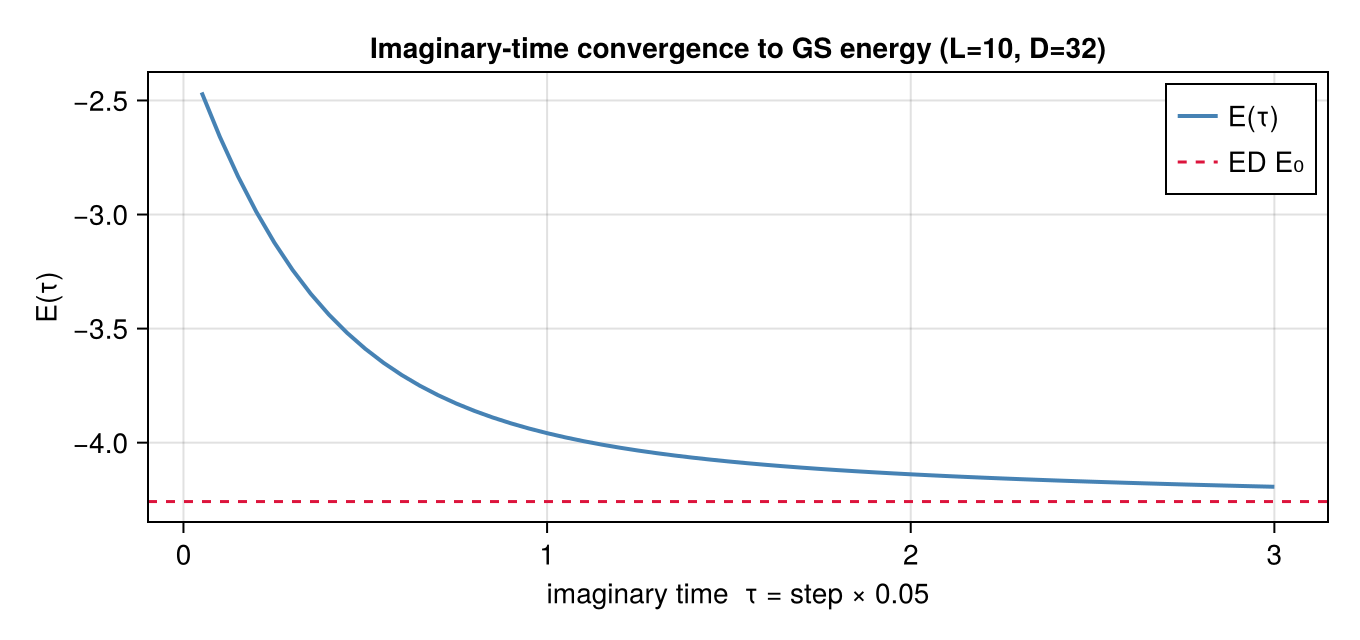

In [5]:
fig = Figure(size=(680, 320))
ax  = Axis(fig[1,1];
    title  = "Imaginary-time convergence to GS energy (L=$L, D=$D)",
    xlabel = "imaginary time  τ = step × $dτ",
    ylabel = "E(τ)",
)
lines!(ax, dτ .* (1:nsteps), E_history; color=:steelblue, linewidth=2, label="E(τ)")
hlines!(ax, [gs_ed.energy]; color=:crimson, linestyle=:dash, label="ED E₀")
axislegend(ax)
fig

## Part B — MBL: disorder realizations and entanglement saturation

`disorder_realization(L, Uniform(-W, W), rng)` draws $L$ random on-site fields.
Passing the field vector to `XXZ(g; h=h_vec)` builds the disordered Hamiltonian.
We monitor the entanglement entropy of the final state vs disorder strength $W$.

In [6]:
function gs_entropy_disordered(L, W, D=24; dτ=0.05, nsteps=50, seed=42)
    rng  = MersenneTwister(seed)
    h    = disorder_realization(L, Uniform(-W, W), rng)
    g_d  = Chain(L)
    H_d  = XXZ(g_d; J=1.0, Jz=1.0, h=h)
    ψ    = canonicalize(neel_state(g_d; dof=SpinHalf()), LeftCanonical())

    for _ in 1:nsteps
        ψ = trotter_step(ψ, H_d, dτ, SuzukiTrotter(2);
                         axis=ImaginaryTime(), trunc=MaxBondDimTrunc(D))
        ψ = canonicalize(ψ, LeftCanonical())
    end

    ψ_final = canonicalize(ψ, BondCanonical(L÷2))
    sv  = ψ_final.bond_svs[L÷2 + 1].values
    p   = sv.^2 ./ sum(sv.^2)
    -sum(pᵢ -> pᵢ > 0 ? pᵢ * log2(pᵢ) : 0.0, p)
end

# MBL has large sample-to-sample fluctuations, so average over a few realizations
S_clean = mean(gs_entropy_disordered(L, 0.0; seed=s) for s in 1:5)
S_mbl   = mean(gs_entropy_disordered(L, 5.0; seed=s) for s in 1:5)
println("W=0 (clean)      ⟨S⟩ = ", round(S_clean; sigdigits=4), " bits")
println("W=5 (strong MBL) ⟨S⟩ = ", round(S_mbl;   sigdigits=4), " bits")

W=0 (clean)      ⟨S⟩ = 0.6819 bits
W=5 (strong MBL) ⟨S⟩ = 0.1391 bits


In [7]:
# Sweep disorder strength W and average over Nreal disorder realizations
W_vals  = [0.0, 0.5, 1.0, 2.0, 3.5, 5.0]
Nreal   = 5   # keep small for notebook speed; increase to 20+ for publication

S_avg = map(W_vals) do W
    entropies = [gs_entropy_disordered(L, W; seed=seed) for seed in 1:Nreal]
    mean(entropies)
end

println("\nW      ⟨S⟩ (bits)")
for (W, S) in zip(W_vals, S_avg)
    println("  $(lpad(W, 4))   ", round(S; sigdigits=4))
end


W      ⟨S⟩ (bits)
   0.0   0.6819
   0.5   0.5573
   1.0   0.5058
   2.0   0.3222
   3.5   0.1324
   5.0   0.1391


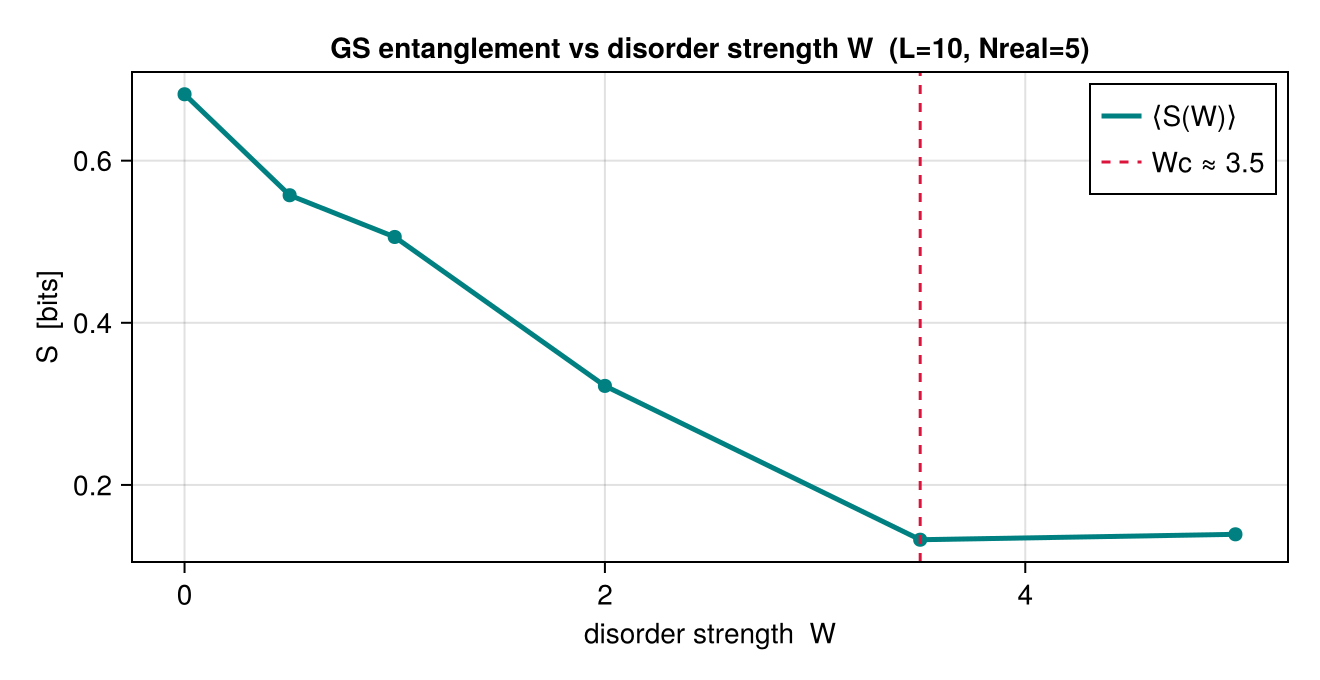

In [8]:
fig2 = Figure(size=(660, 340))
ax2  = Axis(fig2[1,1];
    title  = "GS entanglement vs disorder strength W  (L=$L, Nreal=$Nreal)",
    xlabel = "disorder strength  W",
    ylabel = "S  [bits]",
)
lines!(ax2,  W_vals, S_avg; color=:teal, linewidth=2.5, label="⟨S(W)⟩")
scatter!(ax2, W_vals, S_avg; color=:teal, markersize=10)
vlines!(ax2, [3.5]; color=:crimson, linestyle=:dash, label="Wc ≈ 3.5")
axislegend(ax2)
fig2

In [9]:
# Imaginary-time ground state via the high-level solve interface.
# ψ₀ is a plain canonical MPS; ConstantProtocol carries axis, dt, nsteps and H.
rng_ref = MersenneTwister(1)
h_ref   = disorder_realization(L, Uniform(-1.0, 1.0), rng_ref)
H_dis   = XXZ(g; J=1.0, Jz=1.0, h=h_ref)
ψ0      = canonicalize(neel_state(g; dof=dof), LeftCanonical())

result_imag = solve(
    H_dis,
    Quench(ψ0),
    TEBD(SuzukiTrotter(2), MaxBondDimTrunc(24)),
    ConstantProtocol(ImaginaryTime(), 0.05, 50, H_dis),
)

ψ_gs  = canonicalize(result_imag.state, LeftCanonical())
E_dis = real(expect(ψ_gs, MPO(H_dis))) / real(overlap(ψ_gs, ψ_gs))
println("\nDisordered GS energy via solve: ", round(E_dis; sigdigits=8))


Disordered GS energy via solve: -5.1295612
